# Group-level apples-to-apples comparison (Rutherford 2023 eLife design)

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

BENCH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark'

In [2]:
DESEQ2_DESIGNS = ['no_covariate', 'covariate', 'ruvg_k2']

# phenotype -> contributing study/author labels (same min_n=3 filter as dc.stouffer_group_z,
# e.g. Liver Cancer pools Chen et al. + Roskams-Hieter B et al.; Block et al. dropped, n=2)
sm = pd.read_csv(dc.ZDIR / 'sample_meta.csv')
sm['study'] = sm['batch'].str.replace(r'_Batch_\d+$', '', regex=True)
study_counts = sm[sm.ood_keep].groupby(['phenotype', 'study']).size()
pheno_studies = {}
for (pheno, study), n in study_counts[study_counts >= 3].items():
    pheno_studies.setdefault(pheno, []).append(study.replace(' et al.', ''))


def pheno_label(p):
    studies = sorted(pheno_studies.get(p, []))
    return f"{p} ({', '.join(studies)})" if studies else p

## 1. Gene level -- Stouffer's Z vs DESeq2 Wald stat

In [3]:
GENE_Z_PATH = BENCH / 'group_level_z_test_multidesign.csv'
if GENE_Z_PATH.exists():
    gene_z = pd.read_csv(GENE_Z_PATH)
else:
    parts = [dc.group_level_z_test(deseq2_design=d) for d in DESEQ2_DESIGNS]
    # normative_group_z rows are identical across calls (design only affects the deseq2_* rows) -- keep once
    gene_z = pd.concat([parts[0]] + [p[p.method != 'normative_group_z'] for p in parts[1:]], ignore_index=True)
    gene_z.to_csv(GENE_Z_PATH, index=False)

print('significant phenotypes (hypergeometric padj<0.05) by method x q:')
display(gene_z.groupby(['method', 'q'])['sig_fdr05'].agg(n_sig='sum', n_total='size'))

significant phenotypes (hypergeometric padj<0.05) by method x q:


n_sig  n_total
method              q                   
deseq2_covariate    0.05      4       13
                    0.10      5       13
                    0.15      5       13
                    0.20      4       13
deseq2_no_covariate 0.05      9       13
                    0.10      9       13
                    0.15      7       13
                    0.20      9       13
deseq2_ruvg_k2      0.05      5       13
                    0.10      5       13
                    0.15      6       13
                    0.20      7       13
normative_group_z   0.05      7       14
                    0.10      8       14
                    0.15      8       14
                    0.20      8       14

In [4]:
q05 = gene_z[gene_z.q == 0.05].sort_values(['phenotype', 'method']).reset_index(drop=True)
display(q05[['phenotype', 'method', 'n_sig', 'overlap', 'ref_size', 'pval', 'padj', 'sig_fdr05']])

,phenotype,method,n_sig,overlap,ref_size,pval,padj,sig_fdr05
0,Colorectal Cancer,deseq2_covariate,49,2,300,1.690814e-01,3.079028e-01,False
1,Colorectal Cancer,deseq2_no_covariate,10041,192,300,1.559889e-06,5.647417e-06,True
2,Colorectal Cancer,deseq2_ruvg_k2,88,1,300,7.388209e-01,8.128143e-01,False
3,Colorectal Cancer,normative_group_z,6594,102,300,4.056086e-01,4.921991e-01,False
4,Esophagus Cancer,deseq2_covariate,24,1,300,3.061880e-01,4.592820e-01,False
5,Esophagus Cancer,deseq2_no_covariate,432,12,300,3.201287e-02,5.160283e-02,False
6,Esophagus Cancer,deseq2_ruvg_k2,136,2,300,6.116283e-01,7.027219e-01,False
7,Esophagus Cancer,normative_group_z,3911,58,300,5.863191e-01,6.281020e-01,False
8,HIV,deseq2_covariate,39,3,299,2.071499e-02,4.743126e-02,True
9,HIV,deseq2_no_covariate,52,4,299,7.734114e-03,1.465411e-02,True


In [5]:
# per-(phenotype, study) breakdown at q=0.05 -- phenotypes pooling multiple cohorts (e.g. Liver
# Cancer = Chen et al. + Roskams-Hieter B et al.) get one row per study instead of one combined bar.
import pickle
from scipy.stats import hypergeom, norm
from MixedEffectsModeling.core.calibration import bh_fdr_reject

ref = dc.load_reference()
sym_of = dc.ensg_to_symbol()
gene_names = pickle.load(open(dc.ZDIR / 'gene_names.pkl', 'rb'))
sym_arr = sym_of.reindex(gene_names).values
N_genes = len(gene_names)
group_z = dc.stouffer_group_z()  # {(pheno, study): gz}, min_n=3 already applied

rows = []
norm_sig_by_row, nocov_sig_by_row = {}, {}
design_sig_by_row = {d: {} for d in DESEQ2_DESIGNS}
for (pheno, study), gz in group_z.items():
    dref = ref.get(pheno, set())
    if not dref:
        continue
    finite = np.isfinite(gz)
    p = np.full(len(gz), np.nan)
    p[finite] = 2 * norm.sf(np.abs(gz[finite]))
    reject = np.zeros(len(gz), dtype=bool)
    reject[finite] = bh_fdr_reject(p[finite], q=0.05)
    sig = {s for s in sym_arr[reject] if pd.notna(s)}
    K, n, x = len(dref), len(sig), len(sig & dref)
    pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
    rows.append(dict(phenotype=pheno, study=study, method='normative_group_z', n_sig=n, n_db=x, ref_size=K, pval=pval))
    norm_sig_by_row[(pheno, study)] = sig

sym_of_v = sym_of.copy()
sym_of_v.index = sym_of_v.index.str.split('.').str[0]
for design in DESEQ2_DESIGNS:
    for (study, pheno), res in dc.deseq2_study_results(design).items():
        dref = ref.get(pheno, set())
        if not dref:
            continue
        sig = set(sym_of_v.reindex(res.index[res['padj'] < 0.05]).dropna())
        K, n, x = len(dref), len(sig), len(sig & dref)
        pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
        rows.append(dict(phenotype=pheno, study=study, method=f'deseq2_{design}', n_sig=n, n_db=x, ref_size=K, pval=pval))
        design_sig_by_row[design][(pheno, study)] = sig
        if design == 'no_covariate':
            nocov_sig_by_row[(pheno, study)] = sig

# split normative hits by whether DESeq2(no covariate) also flags them -- unique = independent signal
for (pheno, study), norm_sig in norm_sig_by_row.items():
    dref = ref.get(pheno, set())
    nocov_sig = nocov_sig_by_row.get((pheno, study), set())
    for tag, s in [('normative_unique', norm_sig - nocov_sig), ('normative_overlap', norm_sig & nocov_sig)]:
        K, n, x = len(dref), len(s), len(s & dref)
        pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
        rows.append(dict(phenotype=pheno, study=study, method=tag, n_sig=n, n_db=x, ref_size=K, pval=pval))

gene_z_study = pd.DataFrame(rows)
gene_z_study['has_ot_ref'] = gene_z_study['ref_size'] > 0
display(gene_z_study[gene_z_study.phenotype == 'Liver Cancer'])

,phenotype,study,method,n_sig,n_db,ref_size,pval,has_ot_ref
4,Liver Cancer,Chen et al.,normative_group_z,2041,36,300,1.842272e-01,True
5,Liver Cancer,Roskams-Hieter B et al.,normative_group_z,4078,102,300,3.140051e-08,True
20,Liver Cancer,Chen et al.,deseq2_no_covariate,1269,34,300,8.520094e-04,True
27,Liver Cancer,Roskams-Hieter B et al.,deseq2_no_covariate,15,0,300,1.000000e+00,True
34,Liver Cancer,Chen et al.,deseq2_covariate,16,1,300,2.162407e-01,True
41,Liver Cancer,Roskams-Hieter B et al.,deseq2_covariate,28,2,300,6.647646e-02,True
48,Liver Cancer,Chen et al.,deseq2_ruvg_k2,277,7,300,1.277578e-01,True
55,Liver Cancer,Roskams-Hieter B et al.,deseq2_ruvg_k2,172,4,300,2.625898e-01,True
65,Liver Cancer,Chen et al.,normative_unique,1686,31,300,1.472686e-01,True
66,Liver Cancer,Chen et al.,normative_overlap,355,5,300,6.244096e-01,True


/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

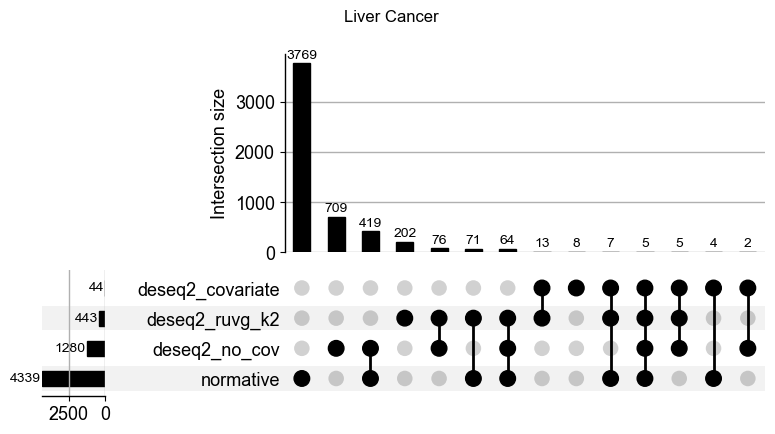

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

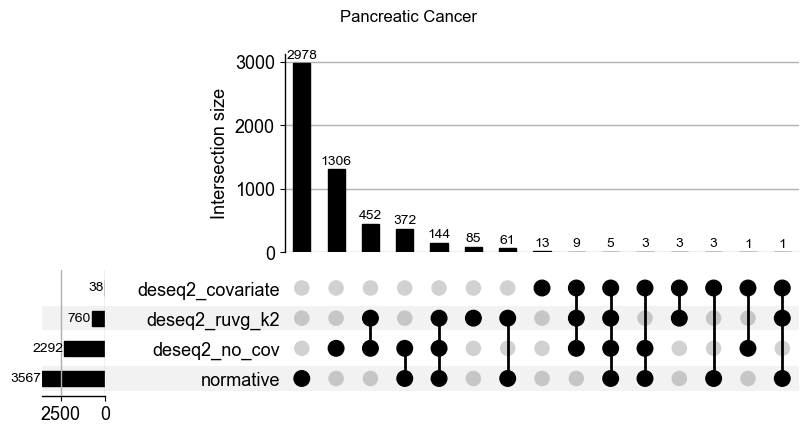

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

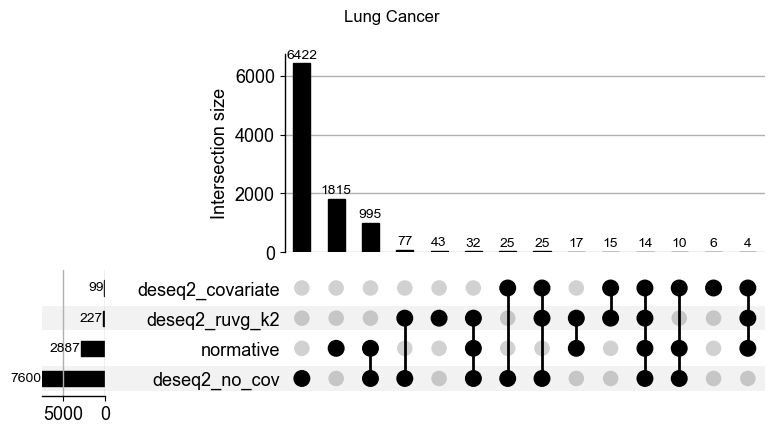

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

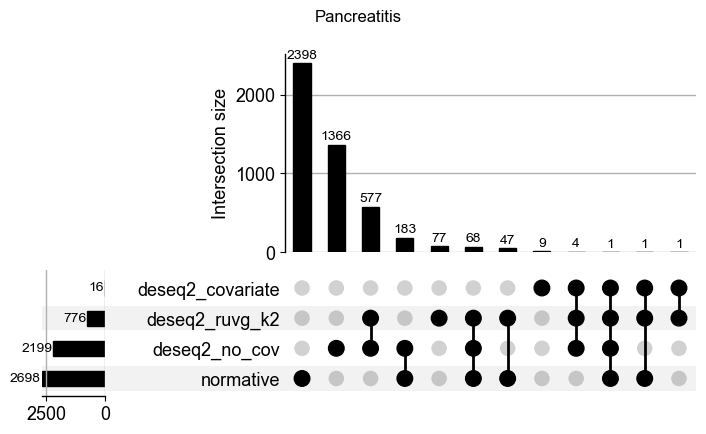

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

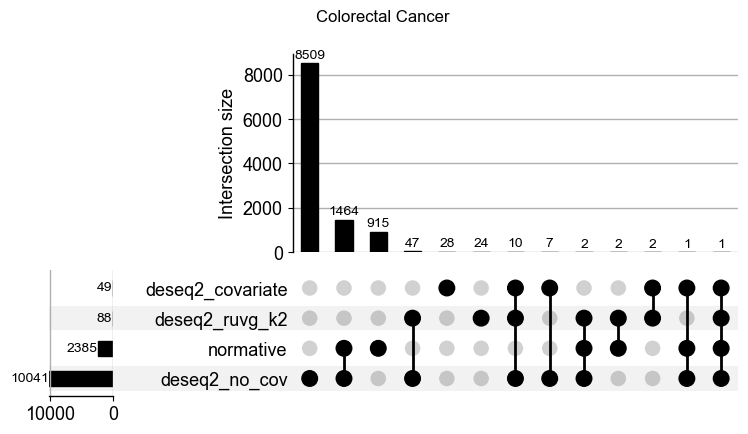

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

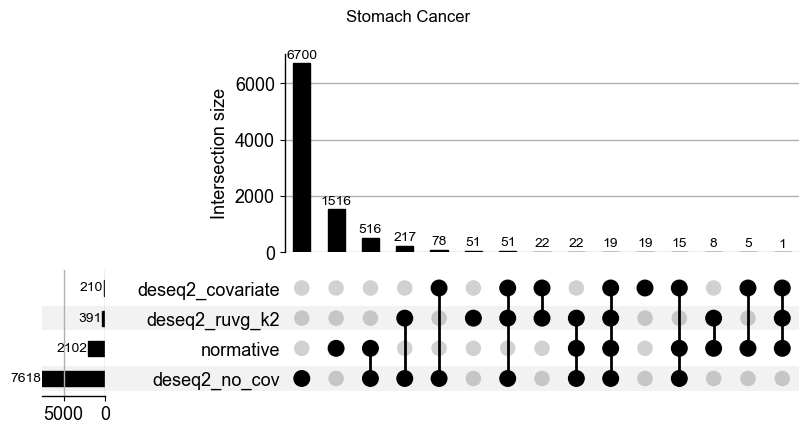

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

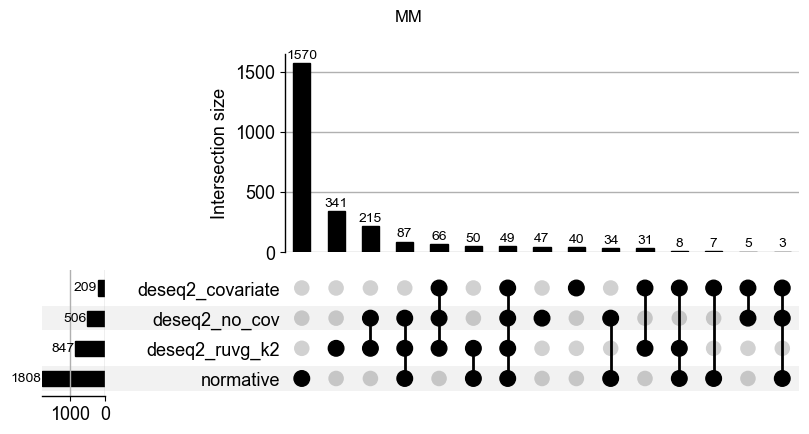

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

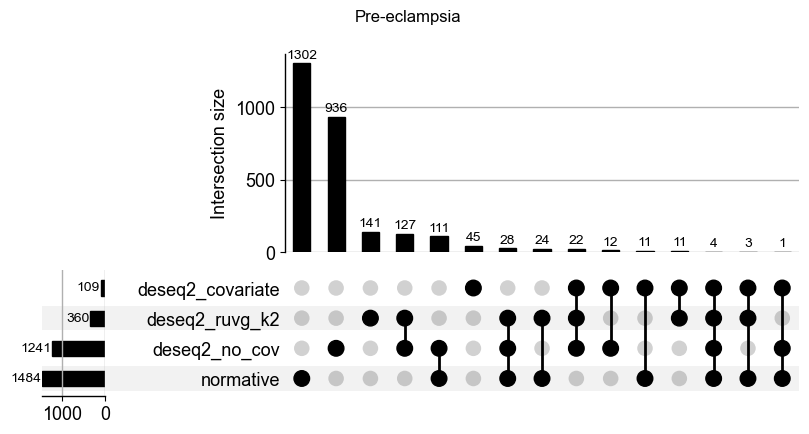

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

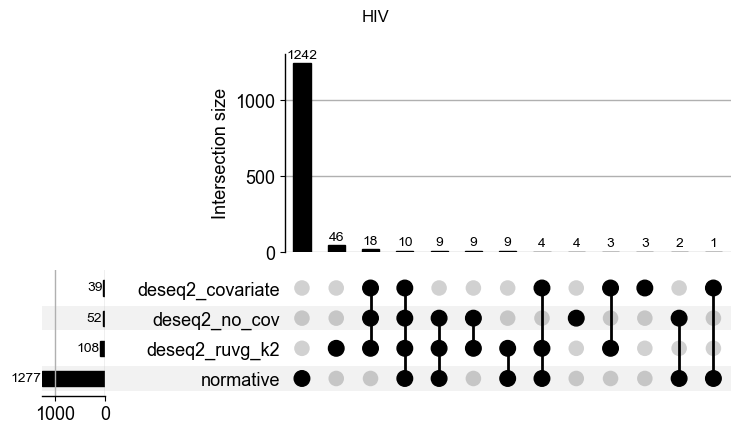

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

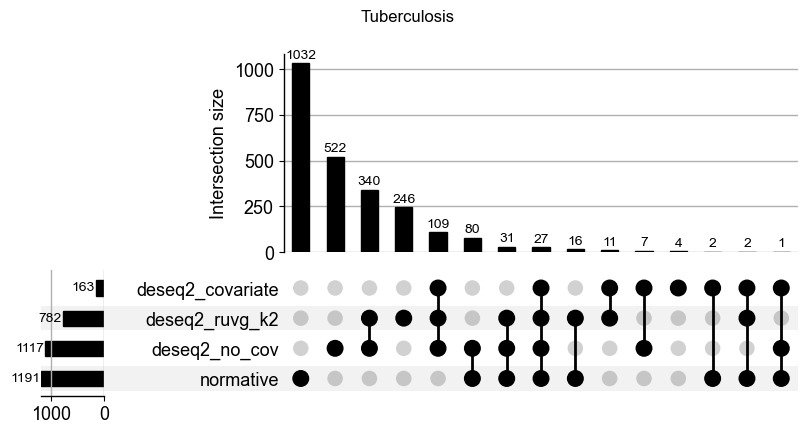

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

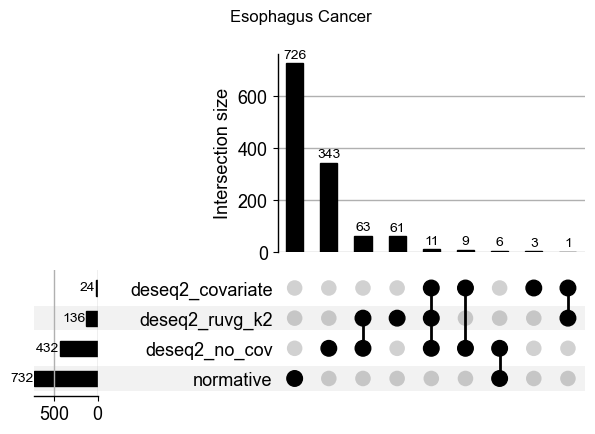

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

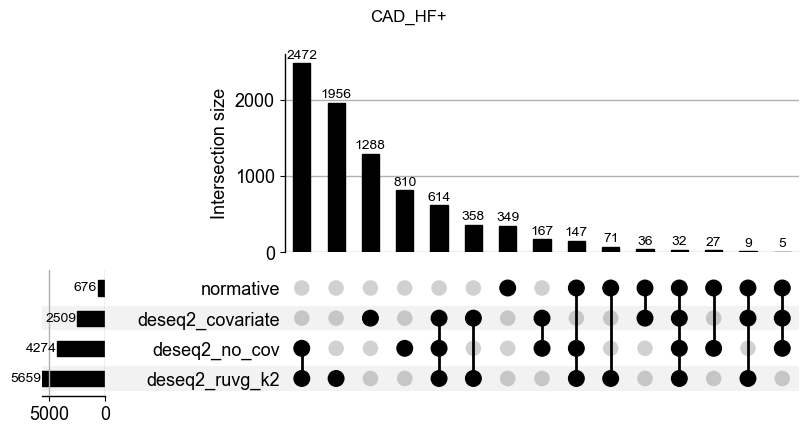

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

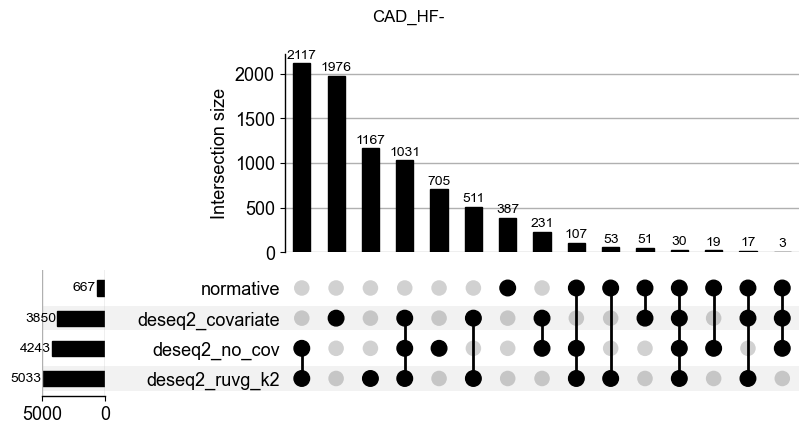

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

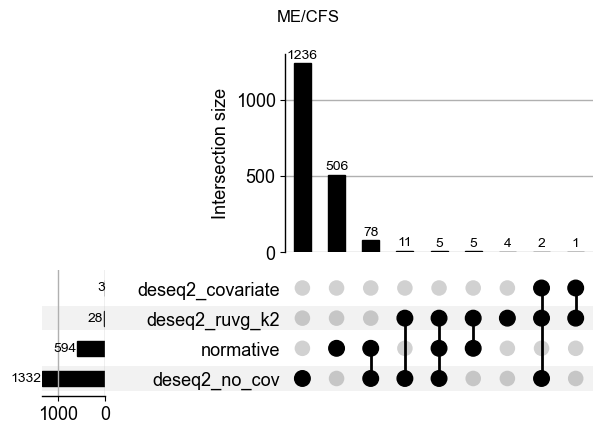

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

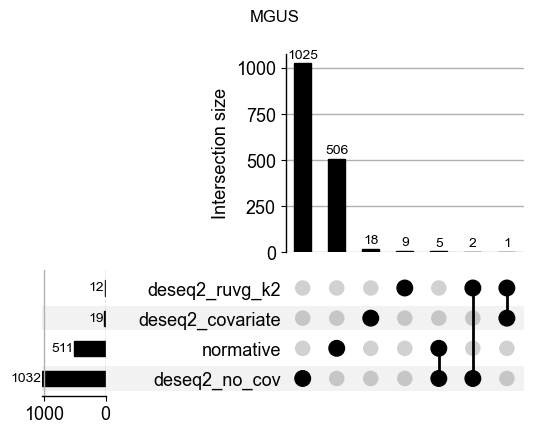

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

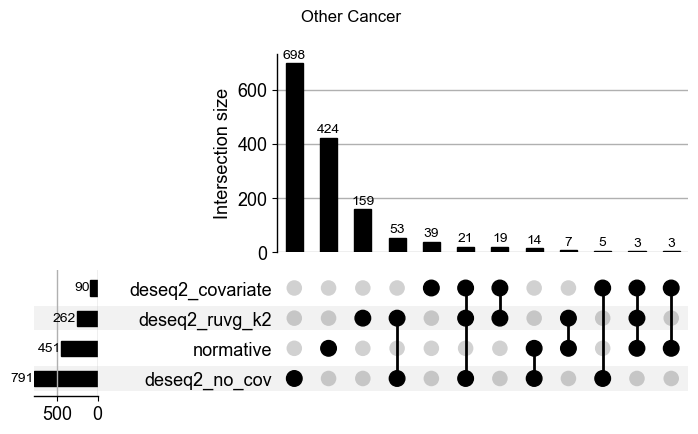

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

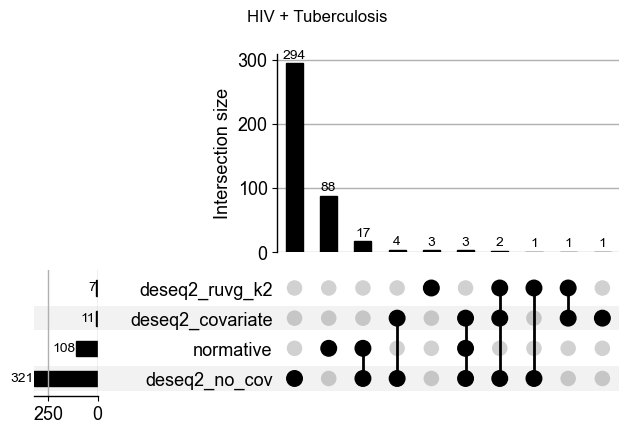

In [6]:
from upsetplot import UpSet, from_contents

venn4 = dc.gene_venn_sets_4way() 
n_show = len(venn4)
phenos = sorted(venn4, key=lambda p: -len(venn4[p]['normative']))[:n_show]

for ph in phenos:
    sets = {k: v for k, v in venn4[ph].items() if len(v) > 0}
    data = from_contents(sets)
    up = UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality')
    fig = plt.figure(figsize=(9, 5))
    up.plot(fig=fig)
    fig.suptitle(ph)
    fig.savefig(BENCH / f"venn4_upset_{ph.replace('/', '-').replace(' ', '_')}.png", dpi=150)
    plt.show()

In [7]:
venn4_all = dc.gene_venn_sets_4way()

def jacc(a, b):
    return len(a & b) / len(a | b) if (a | b) else float("nan")

rows = []
for ph, s in venn4_all.items():
    n, c, r, m = s["deseq2_no_cov"], s["deseq2_covariate"], s["deseq2_ruvg_k2"], s["normative"]
    rows.append(dict(
        phenotype=ph, n_no_cov=len(n), n_cov=len(c), n_ruvg=len(r), n_normative=len(m),
        deseq2_3way_overlap=len(n & c & r), all4_overlap=len(n & c & r & m),
        jacc_norm_nocov=jacc(m, n), jacc_norm_cov=jacc(m, c), jacc_norm_ruvg=jacc(m, r),
        norm_nocov_bias=jacc(m, n) / jacc(m, c) if jacc(m, c) > 0 else float("inf"),
        n_norm_unique=len(m - n - c - r), norm_unique_frac=len(m - n - c - r) / len(m) if m else float("nan"),
    ))
venn4_table = pd.DataFrame(rows).sort_values("norm_nocov_bias", ascending=False).reset_index(drop=True)
venn4_table.to_csv(BENCH / "venn4_summary.csv", index=False)
venn4_table

,phenotype,n_no_cov,n_cov,n_ruvg,n_normative,deseq2_3way_overlap,all4_overlap,jacc_norm_nocov,jacc_norm_cov,jacc_norm_ruvg,norm_nocov_bias,n_norm_unique,norm_unique_frac
0,Esophagus Cancer,432,24,136,732,11,0,0.005181,0.000000,0.000000,inf,726,0.991803
1,MGUS,1032,19,12,511,0,0,0.003251,0.000000,0.000000,inf,506,0.990215
2,ME/CFS,1332,3,28,594,2,0,0.045035,0.000000,0.016340,inf,506,0.851852
3,Colorectal Cancer,10041,49,88,2385,11,1,0.133966,0.000822,0.002026,162.902719,915,0.383648
4,Pancreatitis,2199,16,776,2698,5,1,0.054252,0.000737,0.034853,73.565554,2398,0.888807
5,Pancreatic Cancer,2292,38,760,3567,14,5,0.098219,0.003340,0.051263,29.408497,2978,0.834875
6,Liver Cancer,1280,44,443,4339,10,5,0.095108,0.003664,0.031715,25.958585,3769,0.868633
7,Lung Cancer,7600,99,227,2887,39,14,0.111382,0.009466,0.021989,11.766707,1815,0.628680
8,Pre-eclampsia,1241,109,360,1484,26,4,0.055792,0.012071,0.033053,4.621954,1302,0.877358
9,Stomach Cancer,7618,210,391,2102,70,19,0.062527,0.017606,0.020467,3.551552,1516,0.721218


## 2. Pathway level -- preranked GSEA on the same two rankings

`gp.prerank` (Subramanian 2005 weighted running-sum + gene-label permutation null), same
KEGG_2021_Human + Reactome_2022 housekeeping-filtered library as `4_gene_enrichment.ipynb`.
q<0.05 = confirmatory, q<0.25 = GSEA's own discovery-tier convention
(`Benchmark/FDR_THRESHOLD_RATIONALE.md`).

In [8]:
PATH_GSEA_PATH = BENCH / 'pathway_gsea_db_hit_rates_multidesign.csv'
if PATH_GSEA_PATH.exists():
    path_gsea = pd.read_csv(PATH_GSEA_PATH)
else:
    parts = [dc.group_level_pathway_gsea(save=False, deseq2_design=d) for d in DESEQ2_DESIGNS]
    # normative_group_gsea* rows are identical across calls -- keep once
    path_gsea = pd.concat(
        [parts[0]] + [p[~p.method.str.startswith('normative_group_gsea')] for p in parts[1:]],
        ignore_index=True)
    path_gsea.to_csv(PATH_GSEA_PATH, index=False)

display(path_gsea[path_gsea.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov_gsea,61,25,0.410,True
1,Colorectal Cancer,deseq2_cov_gsea_q025,252,110,0.437,True
2,Colorectal Cancer,deseq2_no_cov_gsea,31,13,0.419,True
3,Colorectal Cancer,deseq2_no_cov_gsea_q025,250,80,0.320,True
4,Colorectal Cancer,deseq2_ruvg_k2_gsea,93,20,0.215,True
...,...,...,...,...,...,...
101,Tuberculosis,deseq2_no_cov_gsea_q025,521,173,0.332,True
102,Tuberculosis,deseq2_ruvg_k2_gsea,172,90,0.523,True
103,Tuberculosis,deseq2_ruvg_k2_gsea_q025,398,165,0.415,True
104,Tuberculosis,normative_group_gsea,713,275,0.386,True


In [ ]:
# per-(phenotype, study) breakdown, mirroring the gene-level cell above -- reuses cached GSEA
# results (gsea_cache/) computed by path-compute, so this is fast (no GSEA rerun).
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import collapse_to_symbols, load_pathway_library, load_symbol_vocab

universe_syms, sym2idx, col2sym = load_symbol_vocab(None)
terms, M = load_pathway_library()
N_syms = len(universe_syms)
ref_path = {ph: dc.reference_pathways(syms, sym2idx, terms, M) for ph, syms in ref.items()}

rows = []
norm_path_sig_by_row, nocov_path_sig_by_row = {}, {}
path_design_sig_by_row = {d: {} for d in DESEQ2_DESIGNS}
for (pheno, study), gz in group_z.items():
    if not ref_path.get(pheno):
        continue
    Zu, Fm = collapse_to_symbols(gz[None, :], col2sym, N_syms)
    rnk = np.where(Fm[0] > 0, Zu[0], np.nan)
    res2d = dc._cached_gsea(f"normative__{pheno}__{study}", rnk, terms, M, universe_syms)
    sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
    d = dc.db_hit_row(pheno, 'normative_group_gsea', sig, ref_path)
    d['study'] = study
    rows.append(d)
    norm_path_sig_by_row[(pheno, study)] = sig

deseq2_summary = pd.read_csv(dc.DESEQ_DIR / 'summary.csv')
for design in DESEQ2_DESIGNS:
    method = f"{dc.DESIGN_LABELS[design]}_gsea"
    for _, r in deseq2_summary[deseq2_summary.design == design].iterrows():
        pheno, study = r.phenotype, r.study
        if not ref_path.get(pheno):
            continue
        path = dc.DESEQ_DIR / design / f"{dc.deseq2_tag(study, pheno)}.csv"
        if not path.exists():
            continue
        res = pd.read_csv(path, index_col=0)
        res.index = res.index.str.split('.').str[0]
        stat = res['stat'].dropna()
        syms = sym_of.reindex(stat.index)
        rnk_df = pd.Series(stat.values, index=syms.values)
        rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
        res2d = dc._cached_gsea(f"{design}__{dc.deseq2_tag(study, pheno)}", rnk_df.values, terms, M, universe_syms)
        sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
        d = dc.db_hit_row(pheno, method, sig, ref_path)
        d['study'] = study
        rows.append(d)
        path_design_sig_by_row[design][(pheno, study)] = sig
        if design == 'no_covariate':
            nocov_path_sig_by_row[(pheno, study)] = sig

for (pheno, study), norm_sig in norm_path_sig_by_row.items():
    nocov_sig = nocov_path_sig_by_row.get((pheno, study), set())
    for tag, s in [('normative_unique_gsea', norm_sig - nocov_sig), ('normative_overlap_gsea', norm_sig & nocov_sig)]:
        d = dc.db_hit_row(pheno, tag, s, ref_path)
        d['study'] = study
        rows.append(d)

path_gsea_study = pd.DataFrame(rows)
display(path_gsea_study[path_gsea_study.phenotype == 'Liver Cancer'])

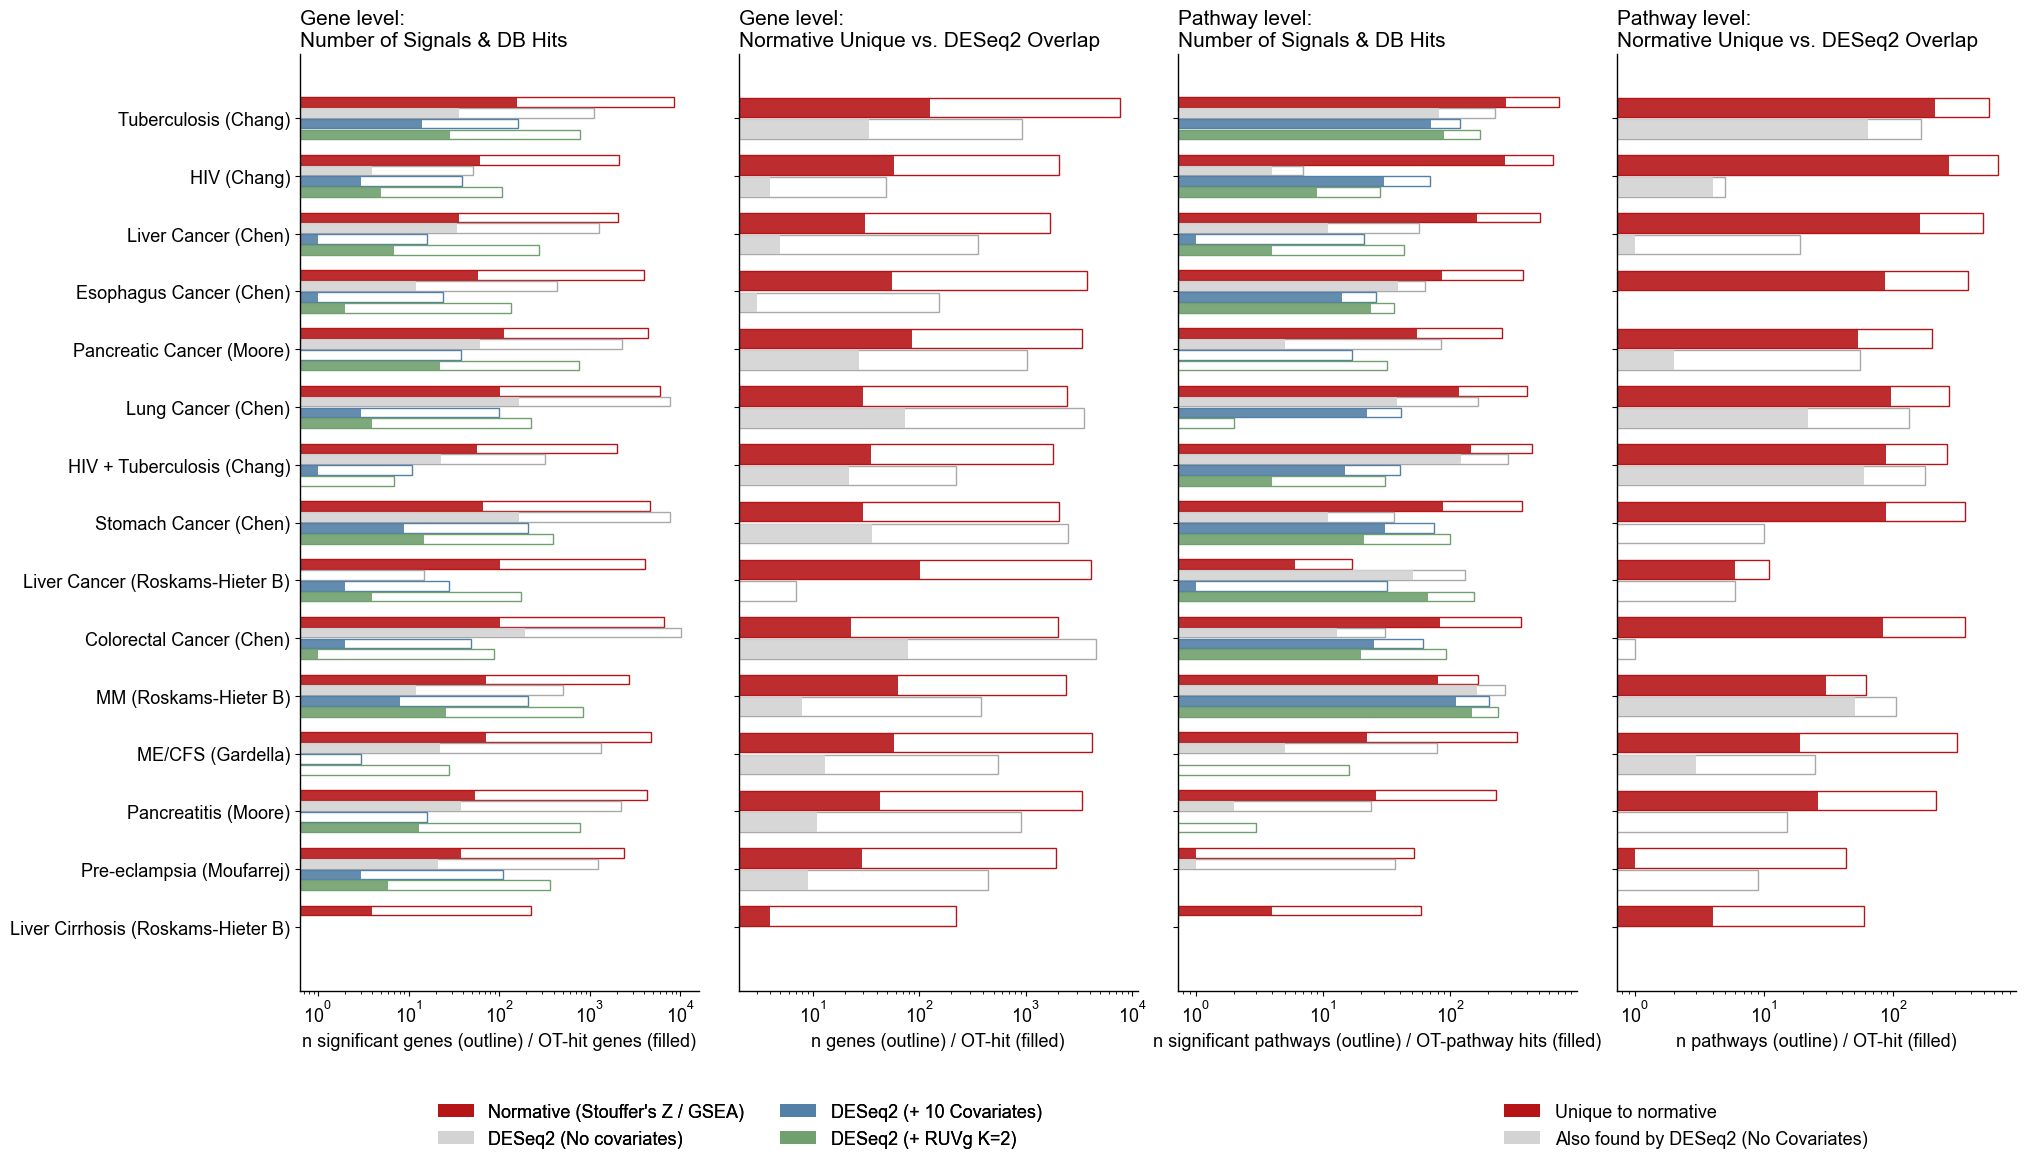

In [10]:
# combined gene + pathway view, shared y-axis (phenotype/study rows)
sub_g = gene_z_study[gene_z_study.has_ot_ref].copy()
sub_g['row_label'] = sub_g.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)
sub_p = path_gsea_study[path_gsea_study.has_ot_ref].copy()
sub_p['row_label'] = sub_p.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)

# rank rows by combined DB-hit count of normative's *independent* signal (gene + pathway unique,
# not just overlap) -- barh plots the last row_ entry at the top, so ascending score puts the
# strongest independent evidence at the top of the figure.
score = {}
for r in set(sub_g.row_label) | set(sub_p.row_label):
    g = sub_g[(sub_g.row_label == r) & (sub_g.method == 'normative_unique')]['n_db'].sum()
    p = sub_p[(sub_p.row_label == r) & (sub_p.method == 'normative_unique_gsea')]['n_db'].sum()
    score[r] = g + p
rows_ = sorted(score, key=lambda r: (score[r], r))
y = np.arange(len(rows_))

gene_methods = ['normative_group_z', 'deseq2_no_covariate', 'deseq2_covariate', 'deseq2_ruvg_k2']
path_methods = ['normative_group_gsea', 'deseq2_no_cov_gsea', 'deseq2_cov_gsea', 'deseq2_ruvg_k2_gsea']
colors = [
    "#B61518",  # Normative: Vivid Red (Highest salience for proposed method)
    '#D3D3D3',  # No covariates: Light Gray (Receded, low reliability)
    "#5280A6",  # + 10 Covariates: Steel Blue (Standard strong baseline 1)
    "#70A06E"   # + RUVg K=2: Green (Standard strong baseline 2, distinct from Blue)
]
level_labels = ['Normative (Stouffer\'s Z / GSEA)', 'DESeq2 (No covariates)', 'DESeq2 (+ 10 Covariates)', 'DESeq2 (+ RUVg K=2)']

# unique (independent of DESeq2 no-cov) vs overlap -- same red/gray as the main panels
uniq_gene_methods = ['normative_unique', 'normative_overlap']
uniq_path_methods = ['normative_unique_gsea', 'normative_overlap_gsea']
uniq_colors = ["#B61518", '#D3D3D3']
uniq_labels = ['Unique to normative', 'Also found by DESeq2 (No Covariates)']


def plot_level(ax, sub, methods, colors_, xlabel, title):
    n_m = len(methods)
    width = 0.75 / n_m
    for j, (m, c) in enumerate(zip(methods, colors_)):
        offset = ((n_m - 1) / 2 - j) * width
        n_sig_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_sig'].sum() for r in rows_]
        n_db_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_db'].sum() for r in rows_]
        edge_color = '#A9A9A9' if c == '#D3D3D3' else c
        ax.barh(y + offset, n_sig_v, height=width * 0.9, facecolor='none', edgecolor=edge_color, linewidth=1)
        ax.barh(y + offset, n_db_v, height=width * 0.9, facecolor=c, edgecolor='none', alpha=0.9)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


fig, (axG, axU_g, axP, axU_p) = plt.subplots(1, 4, figsize=(22, 12), sharey=True)
plot_level(axG, sub_g, gene_methods, colors, 'n significant genes (outline) / OT-hit genes (filled)', 'Gene level:\nNumber of Signals & DB Hits')
plot_level(axU_g, sub_g, uniq_gene_methods, uniq_colors, 'n genes (outline) / OT-hit (filled)', 'Gene level:\nNormative Unique vs. DESeq2 Overlap')
plot_level(axP, sub_p, path_methods, colors, 'n significant pathways (outline) / OT-pathway hits (filled)', 'Pathway level:\nNumber of Signals & DB Hits')
plot_level(axU_p, sub_p, uniq_path_methods, uniq_colors, 'n pathways (outline) / OT-hit (filled)', 'Pathway level:\nNormative Unique vs. DESeq2 Overlap')
axG.set_yticks(y)
axG.set_yticklabels(rows_)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in colors]
uniq_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in uniq_colors]
leg1 = fig.legend(handles, level_labels, loc='upper center', bbox_to_anchor=(0.32, 0.02), ncol=2, frameon=False)
fig.legend(uniq_handles, uniq_labels, loc='upper center', bbox_to_anchor=(0.75, 0.02), ncol=1, frameon=False)
fig.add_artist(leg1)

plt.subplots_adjust(left=0.12, bottom=0.1, wspace=0.1)
fig.savefig(BENCH / 'Figures' / 'group_level_comparison_combined.png', bbox_inches='tight', dpi=300)


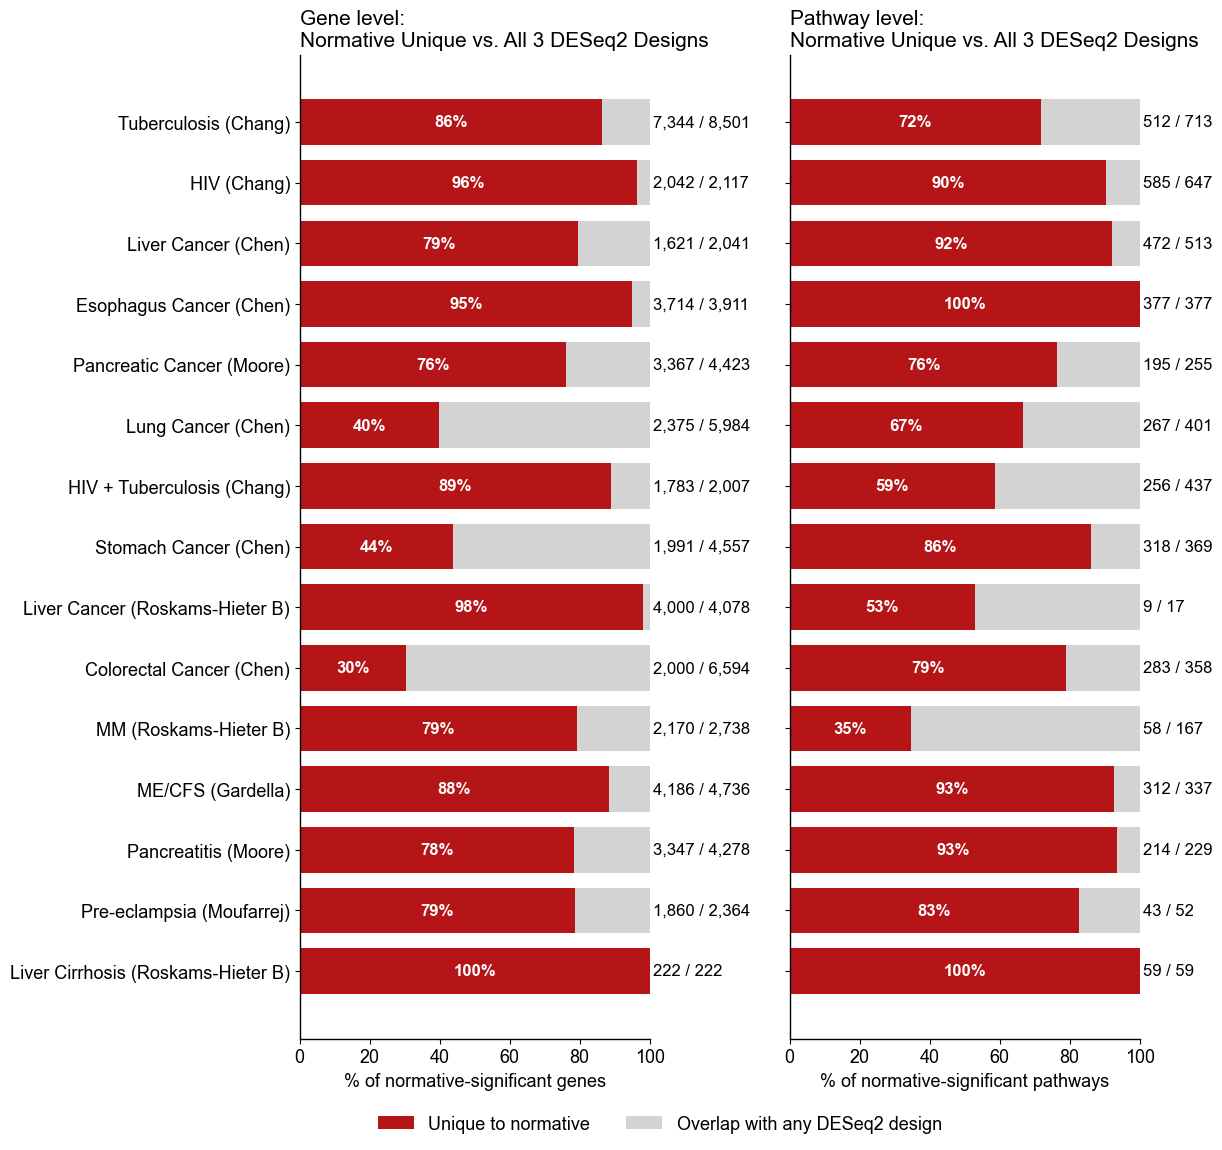

In [13]:
row_key = pd.concat([
    sub_g[['row_label', 'phenotype', 'study']],
    sub_p[['row_label', 'phenotype', 'study']]
]).drop_duplicates('row_label').set_index('row_label')


def unique_frac(sig_by_row, design_sig_by_row, key):
    norm_sig = sig_by_row.get(key)
    if not norm_sig:
        return np.nan, 0, 0
    other = set()
    for d in DESEQ2_DESIGNS:
        other |= design_sig_by_row[d].get(key, set())
    
    n_uniq = len(norm_sig - other)
    n_total = len(norm_sig)
    return 100 * n_uniq / n_total, n_uniq, n_total


gene_uniq, gene_n_uniq, gene_n_total = [], [], []
path_uniq, path_n_uniq, path_n_total = [], [], []

for r in rows_:
    key = (row_key.loc[r, 'phenotype'], row_key.loc[r, 'study'])
    u, nu, nt = unique_frac(norm_sig_by_row, design_sig_by_row, key)
    gene_uniq.append(u); gene_n_uniq.append(nu); gene_n_total.append(nt)
    
    u, nu, nt = unique_frac(norm_path_sig_by_row, path_design_sig_by_row, key)
    path_uniq.append(u); path_n_uniq.append(nu); path_n_total.append(nt)


def plot_unique(ax, uniq, n_uniq, n_total, xlabel, title):
    uniq = np.nan_to_num(uniq)
    ax.barh(y, uniq, color='#B61518', label='Unique to normative (missed by all 3 DESeq2 designs)', height=0.75)
    ax.barh(y, 100 - uniq, left=uniq, color='#D3D3D3', label='Overlaps >=1 DESeq2 design', height=0.75)
    
    for i, (u, nu, nt) in enumerate(zip(uniq, n_uniq, n_total)):
        if u >= 5:
            ax.text(u / 2, i, f'{u:.0f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=12)
        elif u > 0:
            ax.text(u / 2, i, f'{u:.0f}%', va='center', ha='center', color='black', fontsize=12)

        ax.text(101, i, f'{nu:,} / {nt:,}', va='center', ha='left', fontsize=12)

    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


fig, (axG, axP) = plt.subplots(1, 2, figsize=(12, 12), sharey=True)
plot_unique(axG, gene_uniq, gene_n_uniq, gene_n_total, '% of normative-significant genes', 'Gene level:\nNormative Unique vs. All 3 DESeq2 Designs')
plot_unique(axP, path_uniq, path_n_uniq, path_n_total, '% of normative-significant pathways', 'Pathway level:\nNormative Unique vs. All 3 DESeq2 Designs')

axG.set_yticks(y)
axG.set_yticklabels(rows_)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in ['#B61518', '#D3D3D3']]
fig.legend(handles, ['Unique to normative', 'Overlap with any DESeq2 design'], loc='upper center', bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
plt.subplots_adjust(left=0.2, bottom=0.06, wspace=0.4)
fig.savefig(BENCH / 'Figures' / 'venn4_unique_fraction.png', bbox_inches='tight', dpi=300)